In [1]:
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [27]:
X,y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.60, random_state=42)
scaler = StandardScaler()
X = pd.DataFrame(X,columns=['F1','F2'])
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled,columns=['F1','F2'])

In [28]:
inertia =[]
K_range=range(1,11)

In [29]:
for k in K_range:
  kmeans=KMeans(n_clusters=k,random_state=42)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

In [30]:
inertia

[1000.0000000000006,
 297.8954141051723,
 11.575484723104985,
 9.752067977356848,
 8.257175272446279,
 6.917577320416797,
 6.334755391595288,
 5.704177177901426,
 5.060234133532074,
 4.7623618981303935]

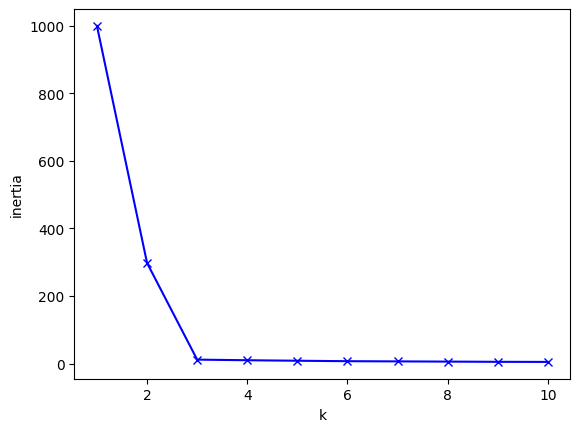

In [31]:
plt.plot(K_range,inertia,'bx-')
plt.xlabel('k')
plt.ylabel('inertia')
plt.show()

In [32]:
kmeans_f=KMeans(n_clusters=3,random_state=42)
cluster_labels=kmeans_f.fit_predict(X_scaled)


In [33]:
X['cluster']=cluster_labels

<Axes: xlabel='F1', ylabel='F2'>

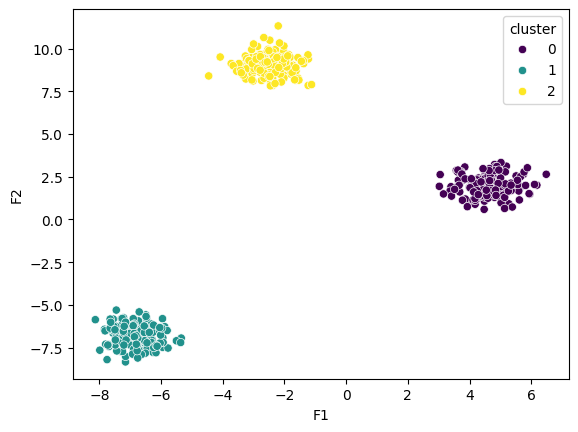

In [34]:
sns.scatterplot(x='F1',y='F2',hue='cluster',data=X,palette='viridis')

In [36]:
from sklearn.datasets import make_moons

In [37]:
X,y_true = make_moons(n_samples=500, noise=0.05, random_state=42)

In [38]:
from sklearn.cluster import KMeans, DBSCAN

In [39]:
df=pd.DataFrame(X,columns=['F1','F2'])

In [40]:
df_scaled=scaler.fit_transform(df)

In [41]:
kmeans=KMeans(n_clusters=2,random_state=42)
kmeans_labels=kmeans.fit_predict(df_scaled)

In [42]:
df['kmeans_cluster']=kmeans_labels

<Axes: xlabel='F1', ylabel='F2'>

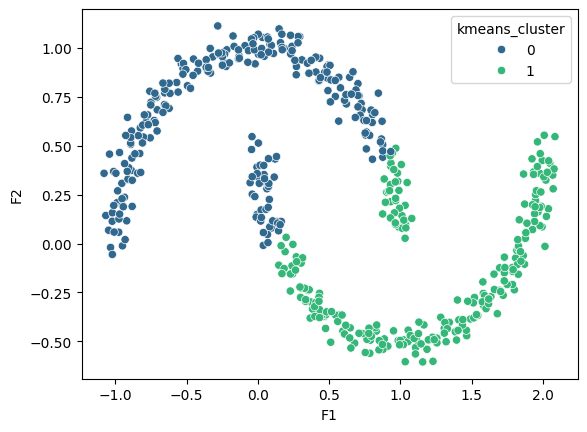

In [43]:
sns.scatterplot(x='F1',y='F2',hue='kmeans_cluster',data=df,palette='viridis')


In [44]:
dbscan=DBSCAN(eps=0.3,min_samples=5)
dbscan_labels=dbscan.fit_predict(df_scaled)

In [45]:
df['dbscan_labels']=dbscan_labels

<Axes: xlabel='F1', ylabel='F2'>

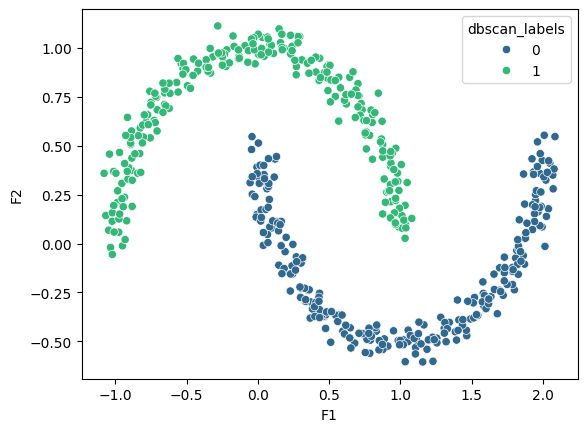

In [46]:
sns.scatterplot(x='F1',y='F2',hue='dbscan_labels',data=df,palette='viridis')


In [47]:
X,y=make_blobs(n_samples=500, n_features=5, centers=3, cluster_std=1.5,random_state=42)


In [48]:
X=pd.DataFrame(X,columns=['F1','F2','F3','F4','F5'])

In [49]:
X_scaled=scaler.fit_transform(X)

In [50]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)

In [53]:
X_pca=pd.DataFrame(X_pca,columns=['PC1','PC2'])

In [54]:
X_pca['label']=y

<Axes: xlabel='PC1', ylabel='PC2'>

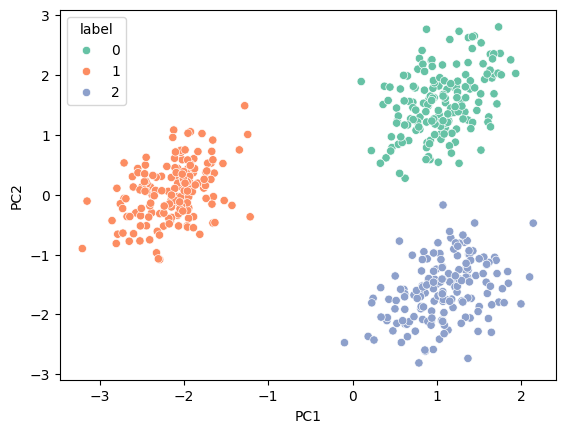

In [57]:
sns.scatterplot(x='PC1',y='PC2',hue='label',data=X_pca,palette='Set2')